# 전체 데이터 + D그룹(피부과) 분석

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chisquare, linregress
from statsmodels.stats.contingency_tables import StratifiedTable
import statsmodels.api as sm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
df['receive_date'] = pd.to_datetime(df['receive_date'], errors='coerce')
df['year'] = df['receive_date'].dt.year
df['month'] = df['receive_date'].dt.month
df['year_month'] = df['receive_date'].dt.to_period('M')

print(f"전체 행 수: {len(df):,} / 기간: {df['receive_date'].min().date()} ~ {df['receive_date'].max().date()}")

전체 행 수: 18,273 / 기간: 2015-01-02 ~ 2025-12-31


## 전체 데이터 EDA

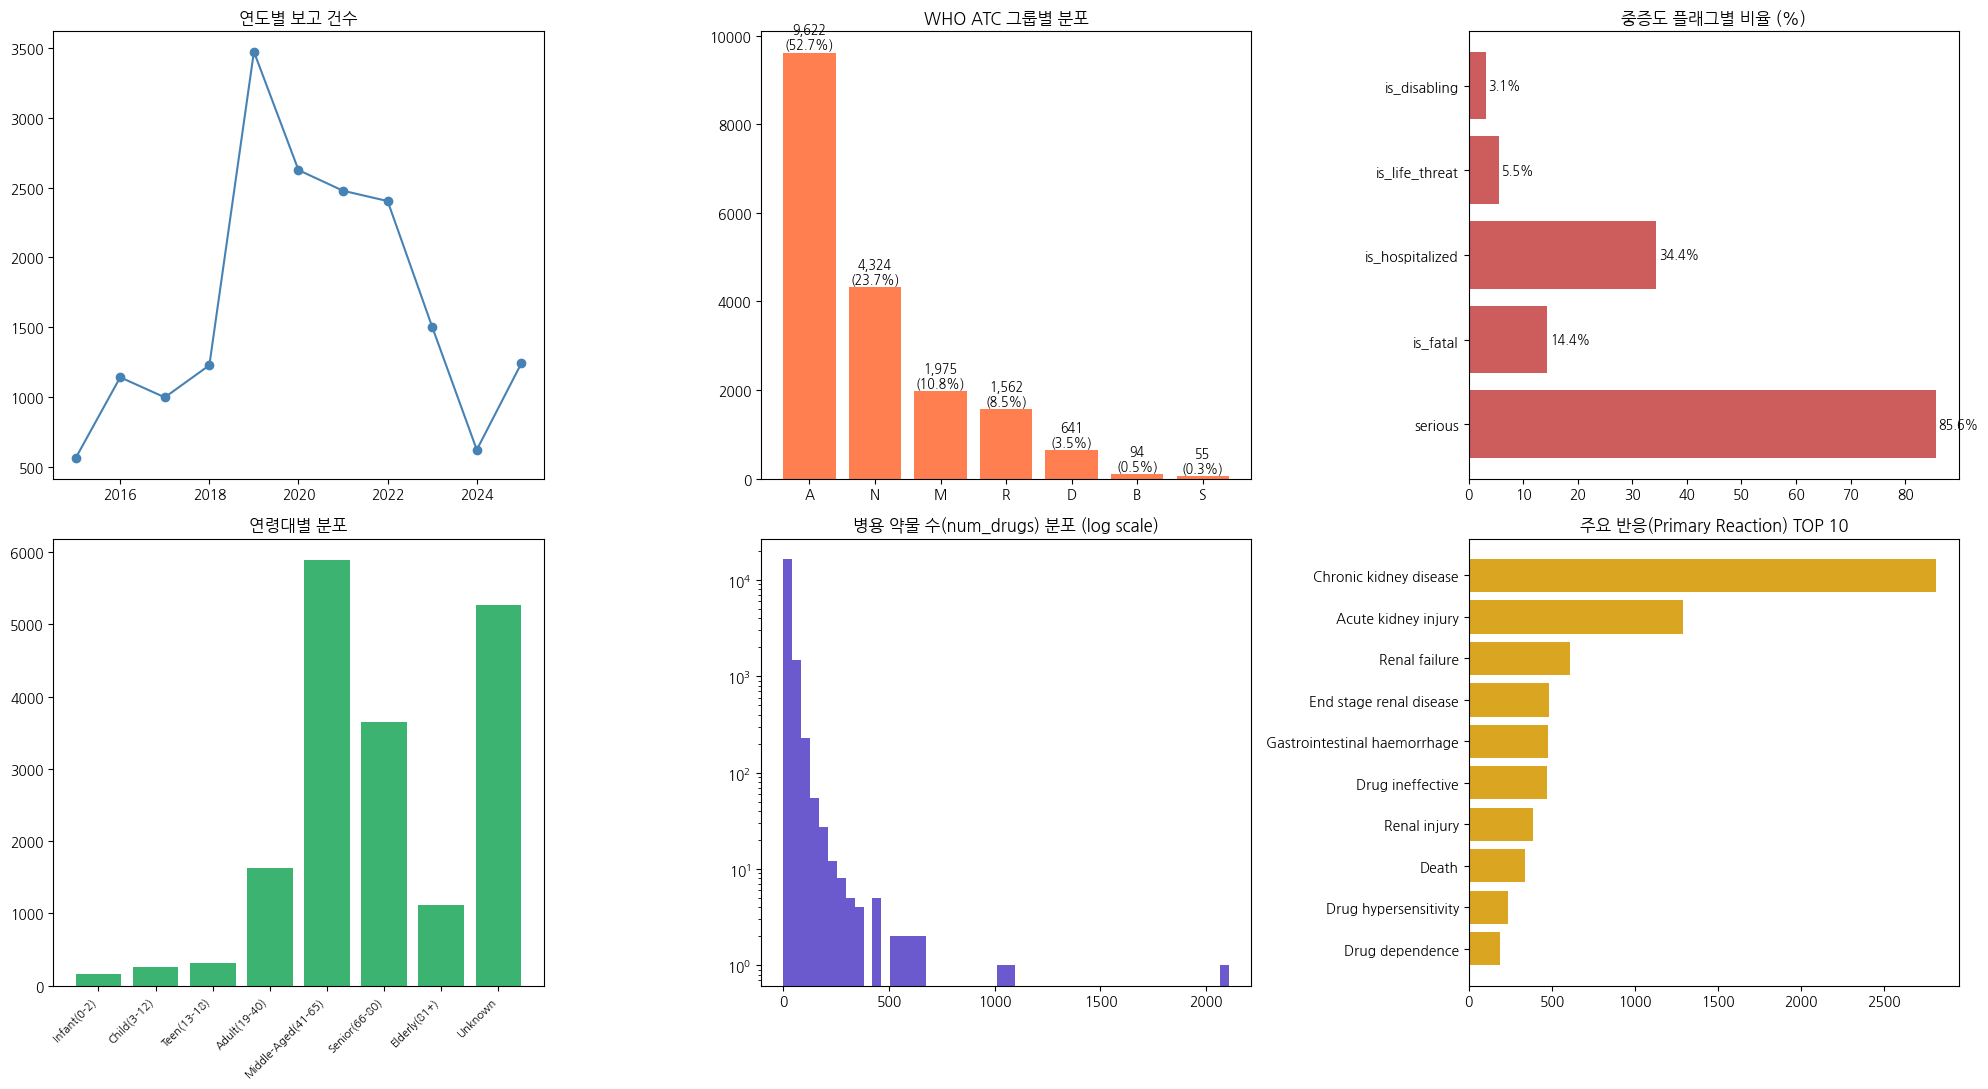

[WHO ATC 그룹 비중]
WHO_ATC
A    52.7%
N    23.7%
M    10.8%
R     8.5%
D     3.5%
B     0.5%
S     0.3%
Name: count, dtype: object

[성별 분포]
patient_sex
Female     9088
Male       6510
Unknown    2675
Name: count, dtype: int64

[num_drugs 기술통계]
count    18273.000000
mean        17.797297
std         33.434406
min          1.000000
25%          3.000000
50%          8.000000
75%         23.000000
max       2108.000000
Name: num_drugs, dtype: float64

[상위 의심약물 TOP 10]
suspect_drug
ESOMEPRAZOLE MAGNESIUM                                                                                               2948
LANSOPRAZOLE                                                                                                         1960
OMEPRAZOLE MAGNESIUM                                                                                                 1200
ASPIRIN; ASPIRIN 81 MG; ASPIRIN 325 MG                                                                               1097
IBUPROFEN; IBUPROFEN CAPSULES 20

In [2]:
# 연도별 추이, ATC 분포, 중증도 플래그, 연령대 분포, 병용약물 수, 주요 반응 TOP10
yearly = df.groupby('year').size()
atc_counts = df['WHO_ATC'].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0,0].plot(yearly.index, yearly.values, marker='o', color='steelblue')
axes[0,0].set_title('연도별 보고 건수', fontweight='bold')

axes[0,1].bar(atc_counts.index, atc_counts.values, color='coral')
axes[0,1].set_title('WHO ATC 그룹별 분포', fontweight='bold')
for i, v in enumerate(atc_counts.values):
    axes[0,1].text(i, v+100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

severity_flags = ['serious', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
severity_data = [(df[c]=='Yes').mean()*100 if c=='serious' else df[c].mean()*100 for c in severity_flags]
axes[0,2].barh(severity_flags, severity_data, color='indianred')
axes[0,2].set_title('중증도 플래그별 비율 (%)')
for i, v in enumerate(severity_data):
    axes[0,2].text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=9)

age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
age_counts = df['age_group'].value_counts().reindex(age_order).fillna(0)
axes[1,0].bar(range(len(age_counts)), age_counts.values, color='mediumseagreen')
axes[1,0].set_xticks(range(len(age_counts)))
axes[1,0].set_xticklabels(age_counts.index, rotation=45, ha='right', fontsize=8)
axes[1,0].set_title('연령대별 분포')

axes[1,1].hist(df['num_drugs'], bins=50, color='slateblue', log=True)
axes[1,1].set_title('병용 약물 수(num_drugs) 분포 (log scale)')

top_reactions = df['primary_reaction'].value_counts().head(10)
axes[1,2].barh(top_reactions.index[::-1], top_reactions.values[::-1], color='goldenrod')
axes[1,2].set_title('주요 반응(Primary Reaction) TOP 10')

plt.tight_layout()
plt.show()

print('[WHO ATC 그룹 비중]'); print((atc_counts / len(df) * 100).round(1).astype(str) + '%')
print('\n[성별 분포]'); print(df['patient_sex'].value_counts())
print('\n[num_drugs 기술통계]'); print(df['num_drugs'].describe())
print('\n[상위 의심약물 TOP 10]'); print(df['suspect_drug'].value_counts().head(10))

atc_severity = df.groupby('WHO_ATC').agg(
    n=('report_id', 'count'), fatal_rate=('is_fatal', 'mean'),
    hosp_rate=('is_hospitalized', 'mean'), life_threat_rate=('is_life_threat', 'mean')
).round(4).sort_values('n', ascending=False)
for col in ['fatal_rate','hosp_rate','life_threat_rate']:
    atc_severity[col] = (atc_severity[col]*100).round(2)
print('\n[ATC 그룹별 중증도 비교 (%)]'); print(atc_severity)

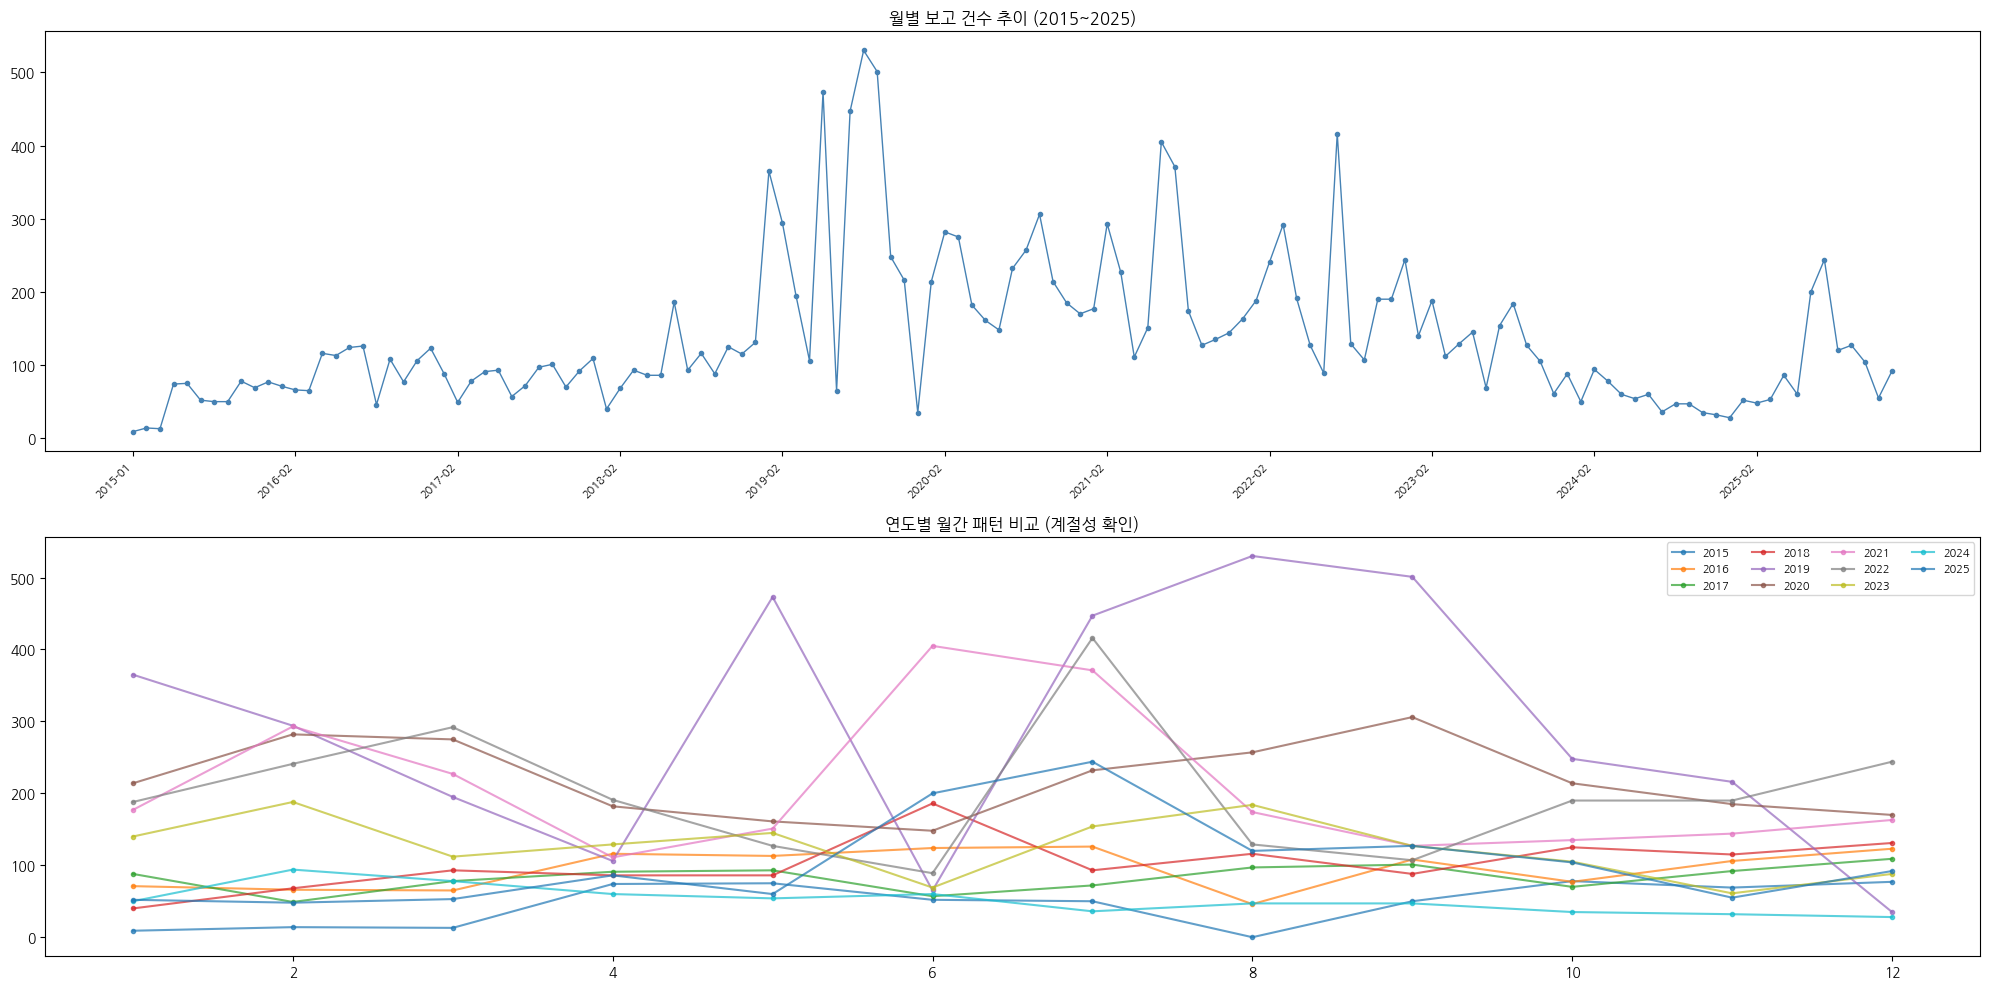

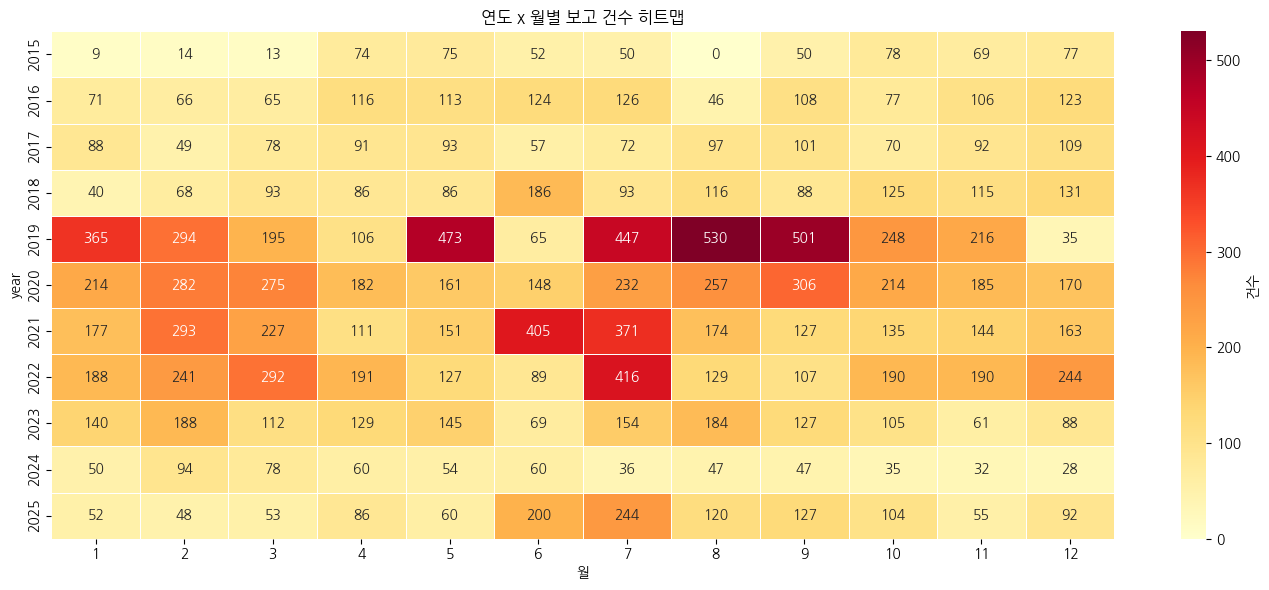

[건수 최다 상위 10개월]
year_month
2019-08    530
2019-09    501
2019-05    473
2019-07    447
2022-07    416
2021-06    405
2021-07    371
2019-01    365
2020-09    306
2019-02    294
dtype: int64


In [3]:
# 월별 보고 건수 추이 + 연도별 계절성 히트맵
monthly = df.groupby('year_month').size()
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(20, 10))
axes[0].plot(monthly.index, monthly.values, marker='o', markersize=3, color='steelblue', linewidth=1)
axes[0].set_title('월별 보고 건수 추이 (2015~2025)')
axes[0].set_xticks(range(0, len(monthly), 12))
axes[0].set_xticklabels(monthly.index[::12], rotation=45, ha='right', fontsize=8)

pivot = df.groupby(['year', 'month']).size().unstack(fill_value=0)
pivot.columns.name = '월'
for year in pivot.index:
    axes[1].plot(pivot.columns, pivot.loc[year], marker='o', markersize=3, label=str(year), alpha=0.7)
axes[1].set_title('연도별 월간 패턴 비교 (계절성 확인)')
axes[1].legend(loc='upper right', ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': '건수'})
plt.title('연도 x 월별 보고 건수 히트맵')
plt.tight_layout()
plt.show()

print('[건수 최다 상위 10개월]'); print(monthly.sort_values(ascending=False).head(10))

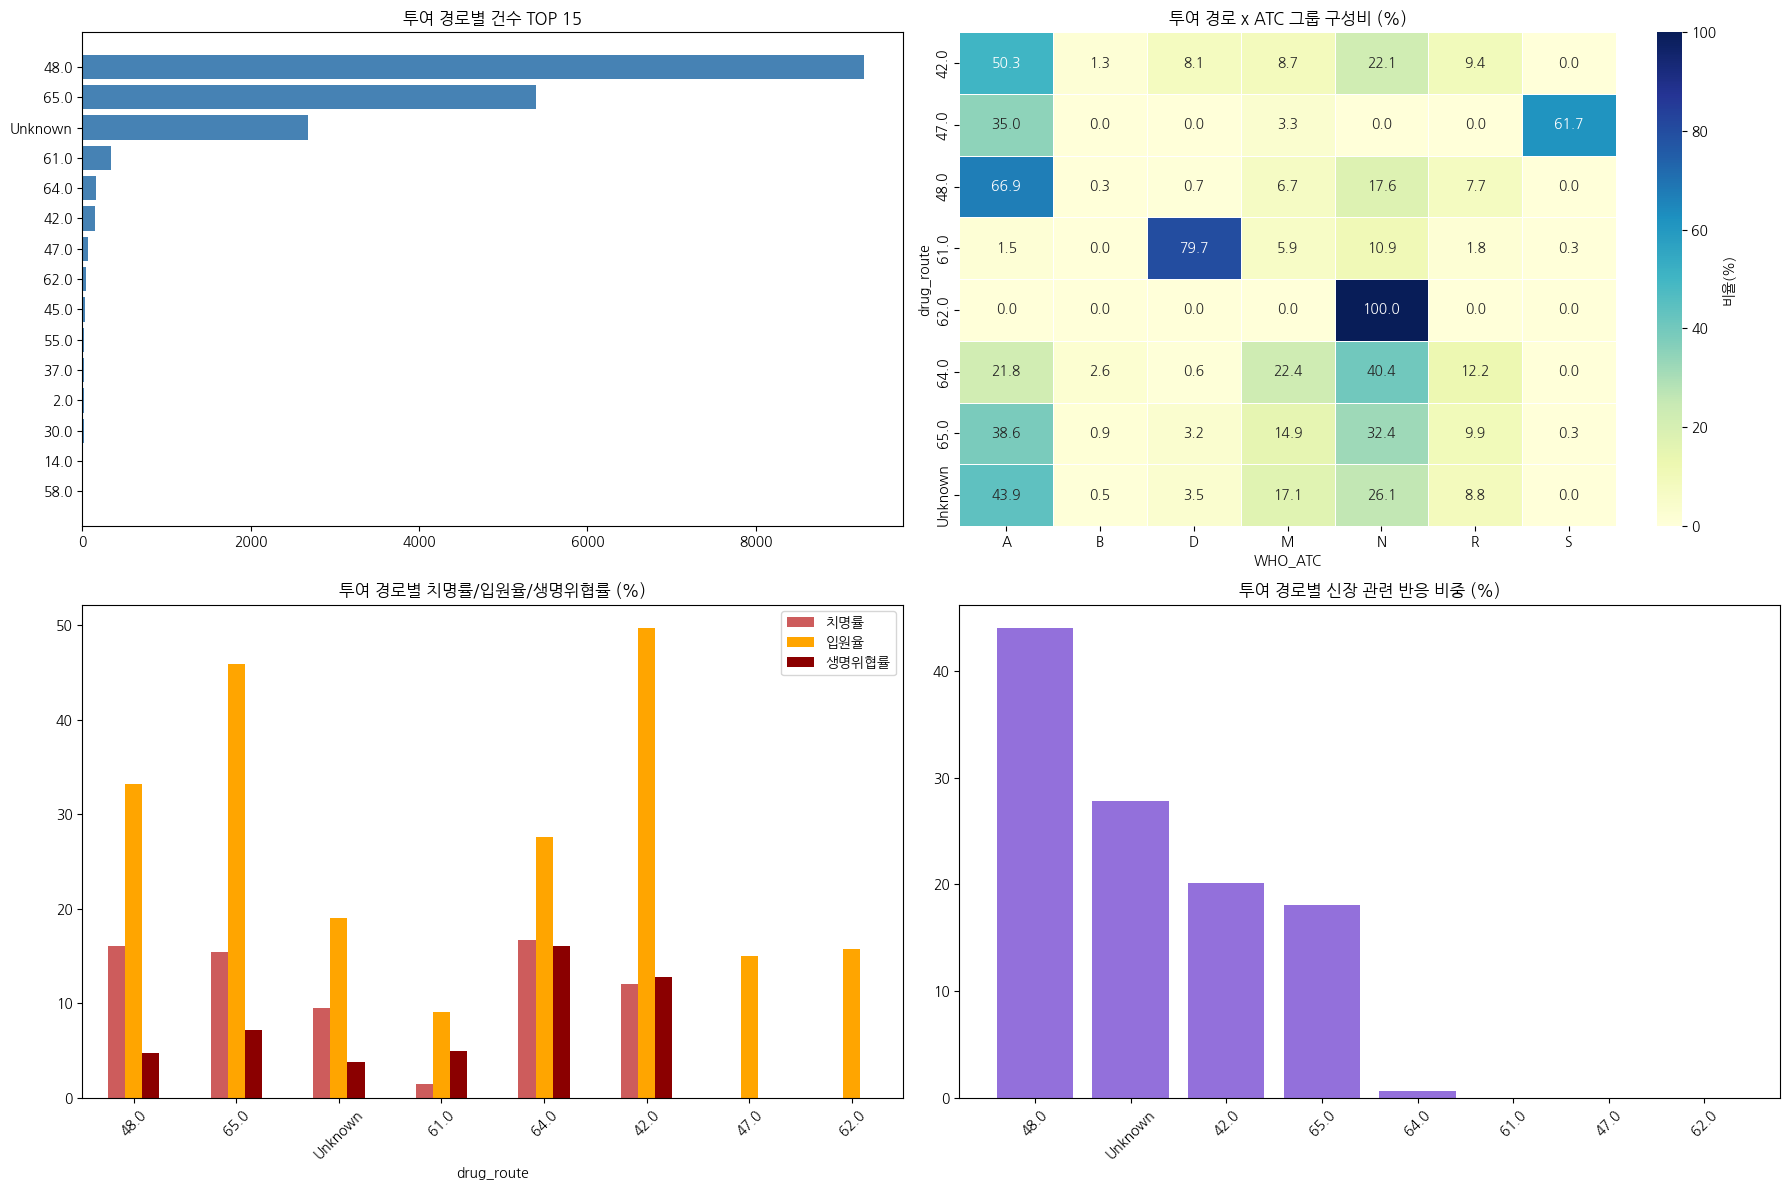

               n  fatal_rate  hosp_rate  life_threat_rate  recovery_rate
drug_route                                                              
48.0        9287       16.03      33.15              4.76          17.35
65.0        5390       15.45      45.83              7.18          24.40
Unknown     2678        9.48      19.01              3.81          13.22
61.0         340        1.47       9.12              5.00          16.18
64.0         156       16.67      27.56             16.03          36.54
42.0         149       12.08      49.66             12.75          41.61
47.0          60        0.00      15.00              0.00          30.00
62.0          38        0.00      15.79              0.00          26.32

투여경로 x 신장반응 카이제곱: chi2=1395.97, p=2.88e-297


In [4]:
# 투여 경로(drug_route) 분포 및 ATC/중증도/신장반응 교차분석
route_counts = df['drug_route'].value_counts()
top_routes = route_counts.head(15)
top_route_list = top_routes.index[:8]
df_route = df[df['drug_route'].isin(top_route_list)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0,0].barh(top_routes.index[::-1], top_routes.values[::-1], color='steelblue')
axes[0,0].set_title('투여 경로별 건수 TOP 15')

route_atc = pd.crosstab(df_route['drug_route'], df_route['WHO_ATC'], normalize='index') * 100
sns.heatmap(route_atc, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0,1], linewidths=0.5, cbar_kws={'label': '비율(%)'})
axes[0,1].set_title('투여 경로 x ATC 그룹 구성비 (%)')

route_severity = df_route.groupby('drug_route').agg(
    n=('report_id','count'), fatal_rate=('is_fatal','mean'),
    hosp_rate=('is_hospitalized','mean'), life_threat_rate=('is_life_threat','mean'),
    recovery_rate=('patient_recovered','mean')
).round(4).sort_values('n', ascending=False)
for col in ['fatal_rate','hosp_rate','life_threat_rate','recovery_rate']:
    route_severity[col] = (route_severity[col]*100).round(2)

route_severity[['fatal_rate','hosp_rate','life_threat_rate']].plot(kind='bar', ax=axes[1,0], color=['indianred','orange','darkred'])
axes[1,0].set_title('투여 경로별 치명률/입원율/생명위협률 (%)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['치명률','입원율','생명위협률'])

df_route['is_renal_reaction'] = df_route['primary_reaction'].str.contains('kidney|renal', case=False, na=False)
renal_by_route = (df_route.groupby('drug_route')['is_renal_reaction'].mean().reindex(top_route_list).sort_values(ascending=False) * 100)
axes[1,1].bar(renal_by_route.index, renal_by_route.values, color='mediumpurple')
axes[1,1].set_title('투여 경로별 신장 관련 반응 비중 (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(route_severity)
contingency_route = pd.crosstab(df_route['drug_route'], df_route['is_renal_reaction'])
chi2, p_val, dof, _ = chi2_contingency(contingency_route)
print(f'\n투여경로 x 신장반응 카이제곱: chi2={chi2:.2f}, p={p_val:.2e}')

조단순(crude) 오즈비: 9.87
공통 오즈비(Common OR): 6.83, 95% CI (6.07, 7.70)
CMH 통계량: 1356.07, p=0.00e+00
동질성 검정(Breslow-Day): p=0.0000


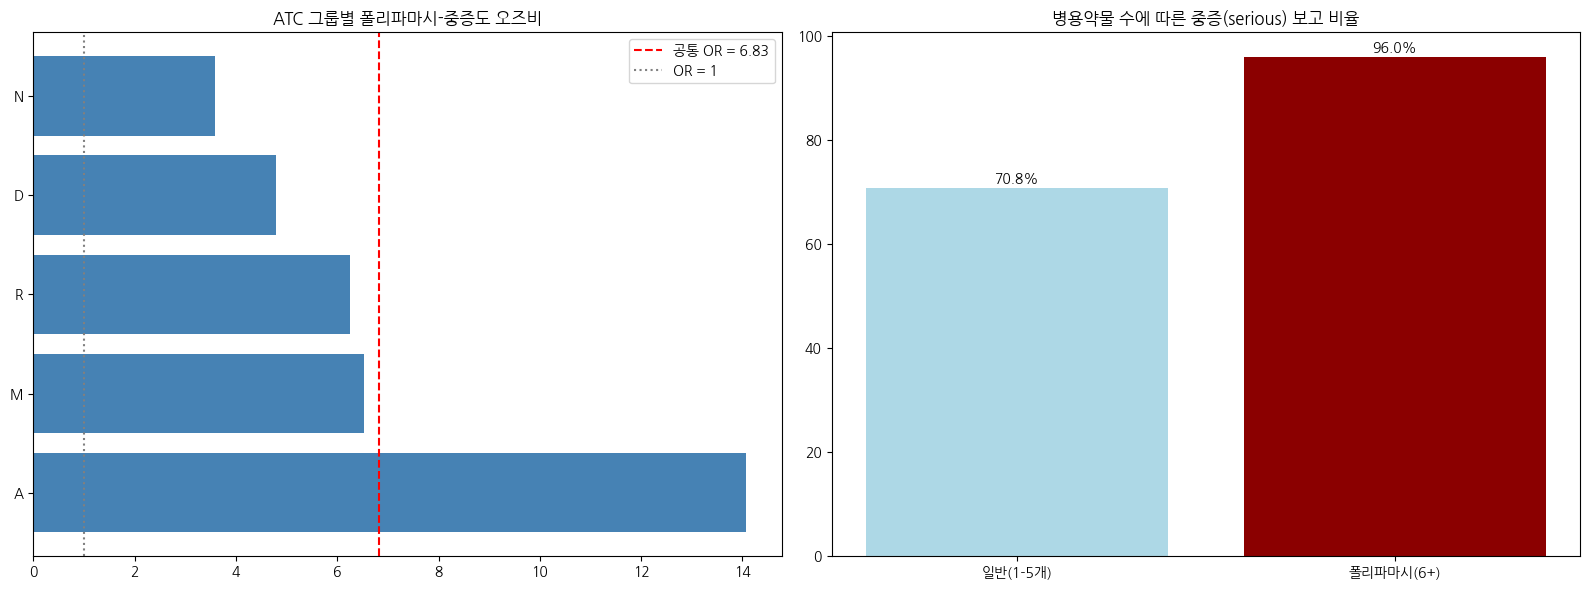

  ATC그룹   표본수    오즈비
3     A  9622  14.07
2     M  1975   6.54
1     R  1562   6.25
4     D   641   4.78
0     N  4324   3.58


In [5]:
# 폴리파마시(병용약물 수) x 중증도, WHO_ATC 층화 CMH 검정 (표본 적은 S,B 그룹 제외)
df_filtered = df[~df['WHO_ATC'].isin(['S', 'B'])].copy()
df_filtered['is_polypharmacy'] = (df_filtered['drug_count_category'] == 'Polypharmacy(6+)')
df_filtered['is_serious'] = (df_filtered['serious'] == 'Yes')

overall_ct = pd.crosstab(df_filtered['is_polypharmacy'], df_filtered['is_serious'])
crude_or = (overall_ct.loc[True,True]*overall_ct.loc[False,False]) / (overall_ct.loc[True,False]*overall_ct.loc[False,True])
print(f'조단순(crude) 오즈비: {crude_or:.2f}')

tables, valid_strata = [], []
for s in df_filtered['WHO_ATC'].dropna().unique():
    sub = df_filtered[df_filtered['WHO_ATC'] == s]
    ct = pd.crosstab(sub['is_polypharmacy'], sub['is_serious'])
    if ct.shape == (2,2) and (ct.values > 0).all():
        tables.append(ct.values); valid_strata.append(s)

st_table = StratifiedTable(tables)
cmh_result = st_table.test_null_odds()
common_or = st_table.oddsratio_pooled
ci_low, ci_high = st_table.oddsratio_pooled_confint()
homogeneity = st_table.test_equal_odds()

print(f'공통 오즈비(Common OR): {common_or:.2f}, 95% CI ({ci_low:.2f}, {ci_high:.2f})')
print(f'CMH 통계량: {cmh_result.statistic:.2f}, p={cmh_result.pvalue:.2e}')
print(f'동질성 검정(Breslow-Day): p={homogeneity.pvalue:.4f}')

strata_or = []
for table in tables:
    tp, tn, fp, fn = table[1,1], table[1,0], table[0,1], table[0,0]
    strata_or.append((tp*fn)/(fp*tn) if fp*tn != 0 else np.nan)
strata_or_df = pd.DataFrame({'ATC그룹': valid_strata, '표본수': [t.sum() for t in tables], '오즈비': strata_or}).sort_values('오즈비', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(strata_or_df['ATC그룹'], strata_or_df['오즈비'], color='steelblue')
axes[0].axvline(common_or, color='red', linestyle='--', label=f'공통 OR = {common_or:.2f}')
axes[0].axvline(1, color='gray', linestyle=':', label='OR = 1')
axes[0].set_title('ATC 그룹별 폴리파마시-중증도 오즈비')
axes[0].legend()

poly_serious_rate = df_filtered.groupby('is_polypharmacy')['is_serious'].mean() * 100
axes[1].bar(['일반(1-5개)', '폴리파마시(6+)'], poly_serious_rate.values, color=['lightblue','darkred'])
axes[1].set_title('병용약물 수에 따른 중증(serious) 보고 비율')
for i, v in enumerate(poly_serious_rate.values):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(strata_or_df.round(2))

## D그룹(피부과) 분석

D그룹 건수: 641 (3.5%)


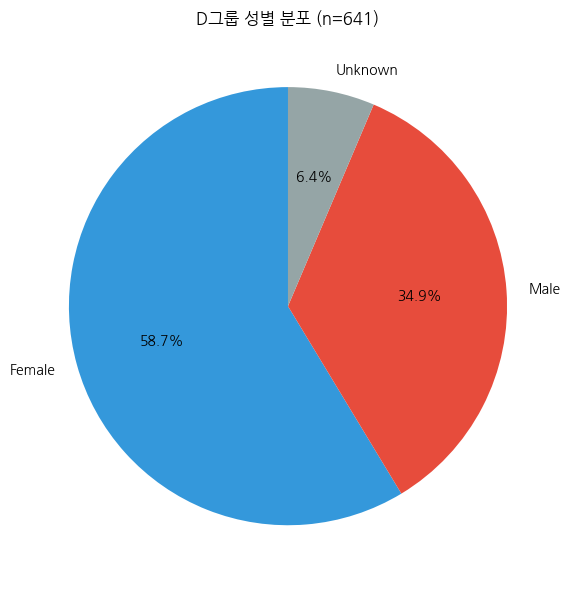

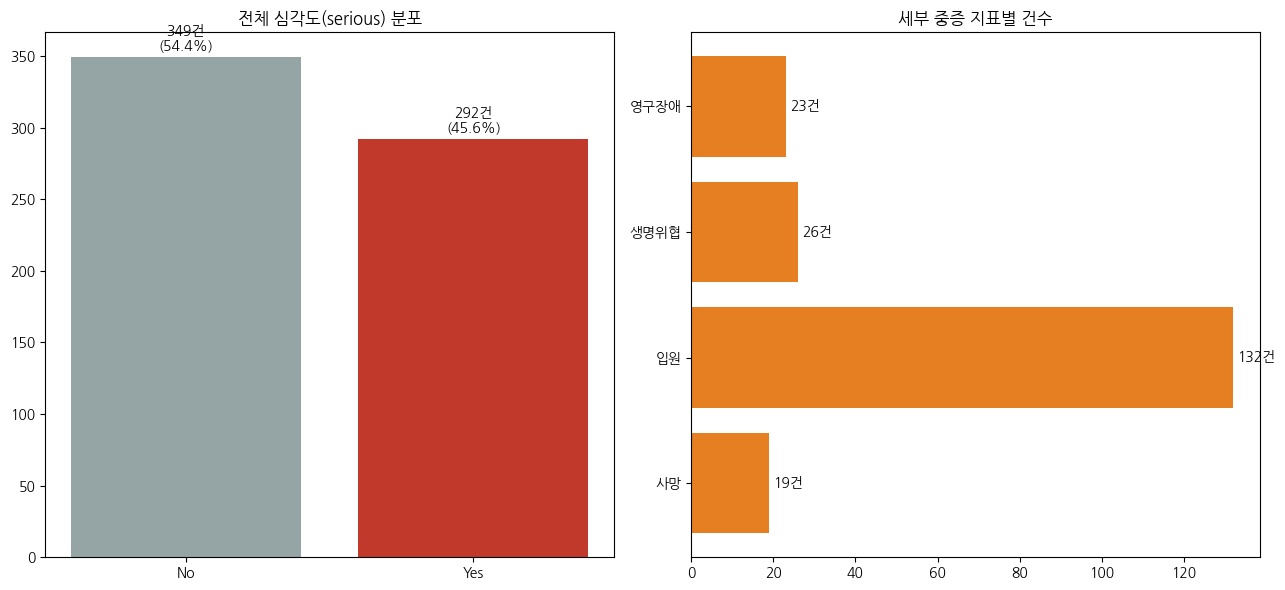

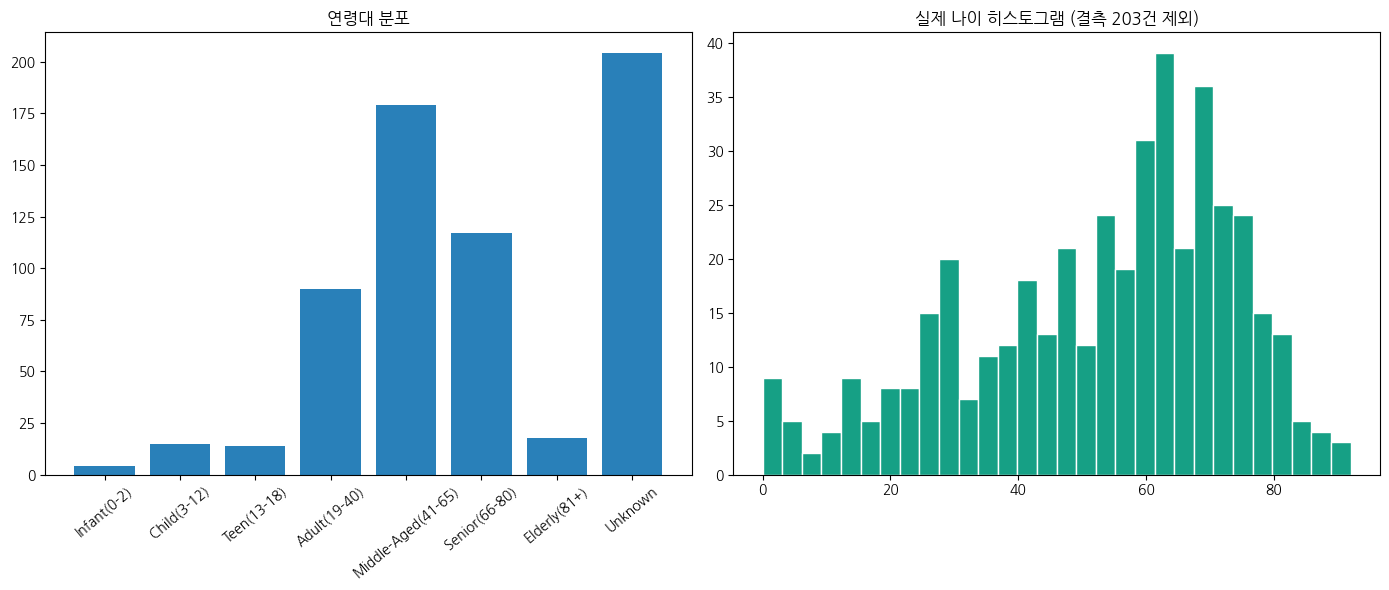

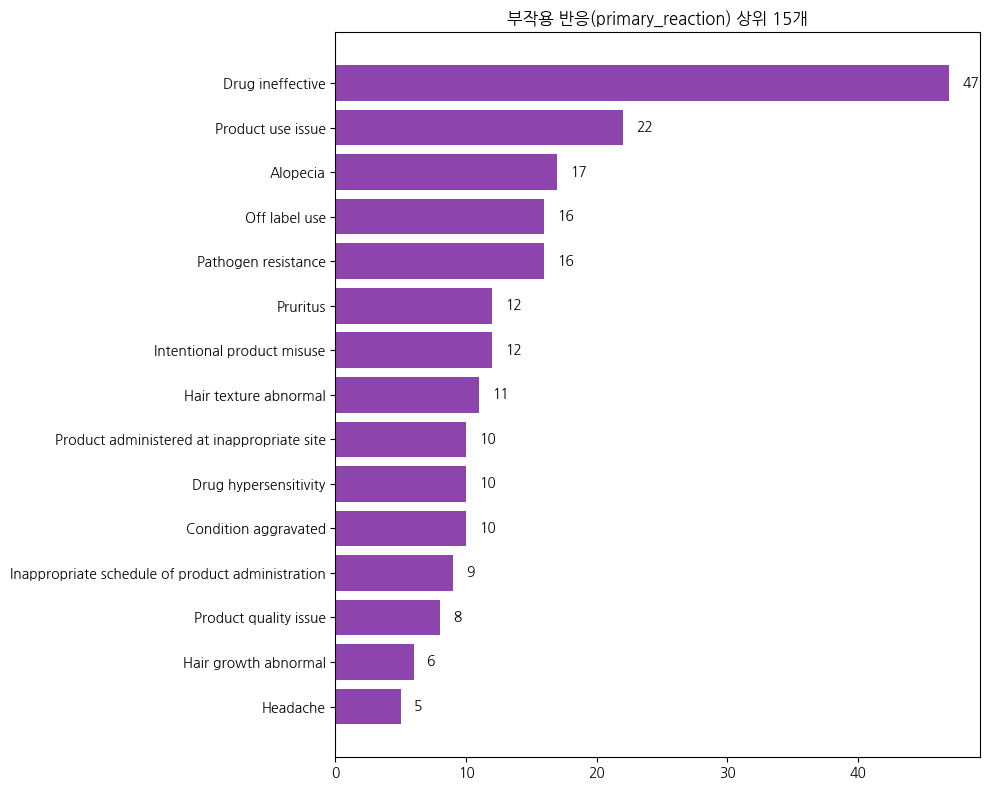

In [6]:
d = df[df['WHO_ATC'] == 'D'].copy()
print(f'D그룹 건수: {len(d)} ({len(d)/len(df)*100:.1f}%)')

# 성별 분포
fig, ax = plt.subplots(figsize=(7, 6))
sex_counts = d['patient_sex'].value_counts()
ax.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
       colors=['#3498db','#e74c3c','#95a5a6'][:len(sex_counts)], startangle=90)
ax.set_title(f'D그룹 성별 분포 (n={len(d)})', fontweight='bold')
plt.tight_layout()
plt.show()

# 심각도 분포
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
serious_counts = d['serious'].value_counts()
axes[0].bar(serious_counts.index, serious_counts.values, color=['#95a5a6','#c0392b'])
axes[0].set_title('전체 심각도(serious) 분포')
for i, v in enumerate(serious_counts.values):
    axes[0].text(i, v+5, f'{v}건\n({v/len(d)*100:.1f}%)', ha='center', fontweight='bold')

severity_flags = ['is_fatal','is_hospitalized','is_life_threat','is_disabling']
severity_counts = d[severity_flags].sum()
axes[1].barh(['사망','입원','생명위협','영구장애'], severity_counts.values, color='#e67e22')
axes[1].set_title('세부 중증 지표별 건수')
for i, v in enumerate(severity_counts.values):
    axes[1].text(v+1, i, f'{v}건', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 연령 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']
age_counts = d['age_group'].value_counts().reindex(age_order, fill_value=0)
axes[0].bar(age_counts.index, age_counts.values, color='#2980b9')
axes[0].set_title('연령대 분포')
axes[0].tick_params(axis='x', rotation=40)

age_numeric = pd.to_numeric(d['patient_age_years'], errors='coerce')
axes[1].hist(age_numeric.dropna(), bins=30, color='#16a085', edgecolor='white')
axes[1].set_title(f'실제 나이 히스토그램 (결측 {age_numeric.isna().sum()}건 제외)')
plt.tight_layout()
plt.show()

# 반응 분포
fig, ax = plt.subplots(figsize=(10, 8))
top_reactions = d['primary_reaction'].value_counts().head(15).sort_values()
ax.barh(top_reactions.index, top_reactions.values, color='#8e44ad')
ax.set_title('부작용 반응(primary_reaction) 상위 15개', fontweight='bold')
for i, v in enumerate(top_reactions.values):
    ax.text(v+1, i, str(v), va='center')
plt.tight_layout()
plt.show()

[전체 vs D그룹 중증도 비교 (%)]
                     전체    D그룹
fatal_rate        14.43   2.96
hosp_rate         34.37  20.59
life_threat_rate   5.54   4.06
recovery_rate     19.33  25.43
serious_rate      85.56  45.55
D그룹 내 미녹시딜/로게인 계열 비중: 45.6%

[전체 vs D그룹 반응 유형 비율 비교 (%)]
                         전체   D그룹
reaction_category_eff            
안전성(부작용) 이슈            94.3  77.2
효능/품질 이슈                5.7  22.8

숫자로 파싱되는 route 값 비율: 85.3% (데이터 이상 확인용)


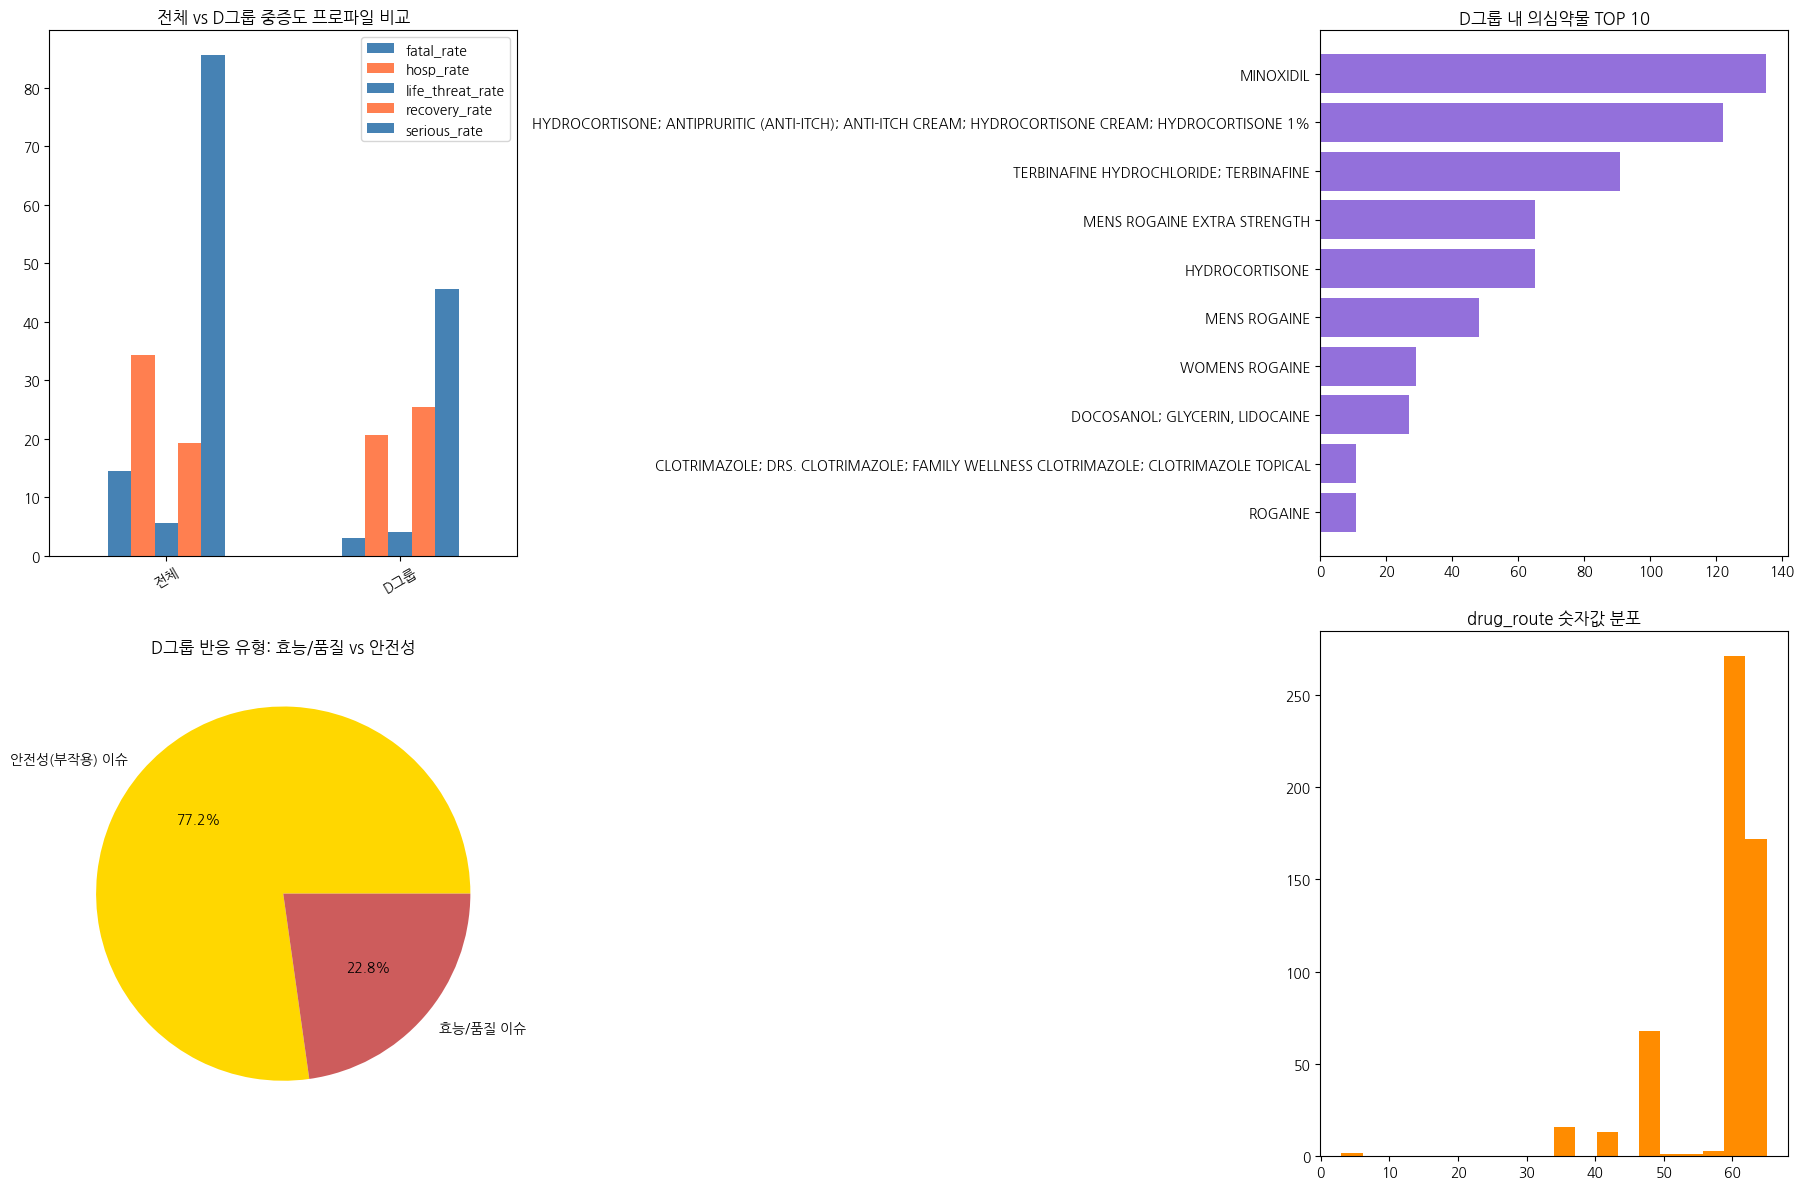


[D그룹 drug_indication TOP 10]
drug_indication
Unknown                                161
Alopecia                               131
Product Used For Unknown Indication    106
Onychomycosis                           24
Oral Herpes                             17
Acute Lymphocytic Leukaemia             15
Adrenal Insufficiency                   15
Trichophytosis                          15
Fungal Infection                         8
Hypertension                             5
Name: count, dtype: int64


In [7]:
# 전체 vs D그룹 비교 + 의심약물 구성 + 반응유형(효능/안전성) + drug_route 이상 + drug_indication
compare_metrics = pd.DataFrame({
    '전체': {
        'fatal_rate': df['is_fatal'].mean()*100, 'hosp_rate': df['is_hospitalized'].mean()*100,
        'life_threat_rate': df['is_life_threat'].mean()*100, 'recovery_rate': df['patient_recovered'].mean()*100,
        'serious_rate': (df['serious']=='Yes').mean()*100,
    },
    'D그룹': {
        'fatal_rate': d['is_fatal'].mean()*100, 'hosp_rate': d['is_hospitalized'].mean()*100,
        'life_threat_rate': d['is_life_threat'].mean()*100, 'recovery_rate': d['patient_recovered'].mean()*100,
        'serious_rate': (d['serious']=='Yes').mean()*100,
    }
}).round(2)
print('[전체 vs D그룹 중증도 비교 (%)]'); print(compare_metrics)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
compare_metrics.T.plot(kind='bar', ax=axes[0,0], color=['steelblue','coral'])
axes[0,0].set_title('전체 vs D그룹 중증도 프로파일 비교')
axes[0,0].tick_params(axis='x', rotation=30)

top_d_drugs = d['suspect_drug'].value_counts().head(10)
axes[0,1].barh(top_d_drugs.index[::-1], top_d_drugs.values[::-1], color='mediumpurple')
axes[0,1].set_title('D그룹 내 의심약물 TOP 10')
minoxidil_share = d['suspect_drug'].str.contains('MINOXIDIL|ROGAINE', case=False, na=False).mean()
print(f'D그룹 내 미녹시딜/로게인 계열 비중: {minoxidil_share*100:.1f}%')

efficacy_keywords = ['ineffective','Off label','inappropriate','misuse','quality','resistance','aggravated','administered']
def classify_reaction(r):
    return '효능/품질 이슈' if any(k.lower() in str(r).lower() for k in efficacy_keywords) else '안전성(부작용) 이슈'

d['reaction_category_eff'] = d['primary_reaction'].apply(classify_reaction)
reaction_cat_counts = d['reaction_category_eff'].value_counts()
axes[1,0].pie(reaction_cat_counts.values, labels=reaction_cat_counts.index, autopct='%1.1f%%', colors=['gold','indianred'])
axes[1,0].set_title('D그룹 반응 유형: 효능/품질 vs 안전성')

df['reaction_category_eff'] = df['primary_reaction'].apply(classify_reaction)
cat_compare = pd.DataFrame({
    '전체': (df['reaction_category_eff'].value_counts(normalize=True)*100).round(1),
    'D그룹': (d['reaction_category_eff'].value_counts(normalize=True)*100).round(1),
})
print('\n[전체 vs D그룹 반응 유형 비율 비교 (%)]'); print(cat_compare)

numeric_route = pd.to_numeric(d['drug_route'], errors='coerce')
print(f'\n숫자로 파싱되는 route 값 비율: {numeric_route.notna().mean()*100:.1f}% (데이터 이상 확인용)')
axes[1,1].hist(numeric_route.dropna(), bins=20, color='darkorange')
axes[1,1].set_title('drug_route 숫자값 분포')
plt.tight_layout()
plt.show()

print('\n[D그룹 drug_indication TOP 10]'); print(d['drug_indication'].value_counts().head(10))

reaction_category
진짜 부작용      419
오남용/제품불만    222
Name: count, dtype: int64
reaction_category
진짜 부작용      65.4
오남용/제품불만    34.6
Name: proportion, dtype: float64


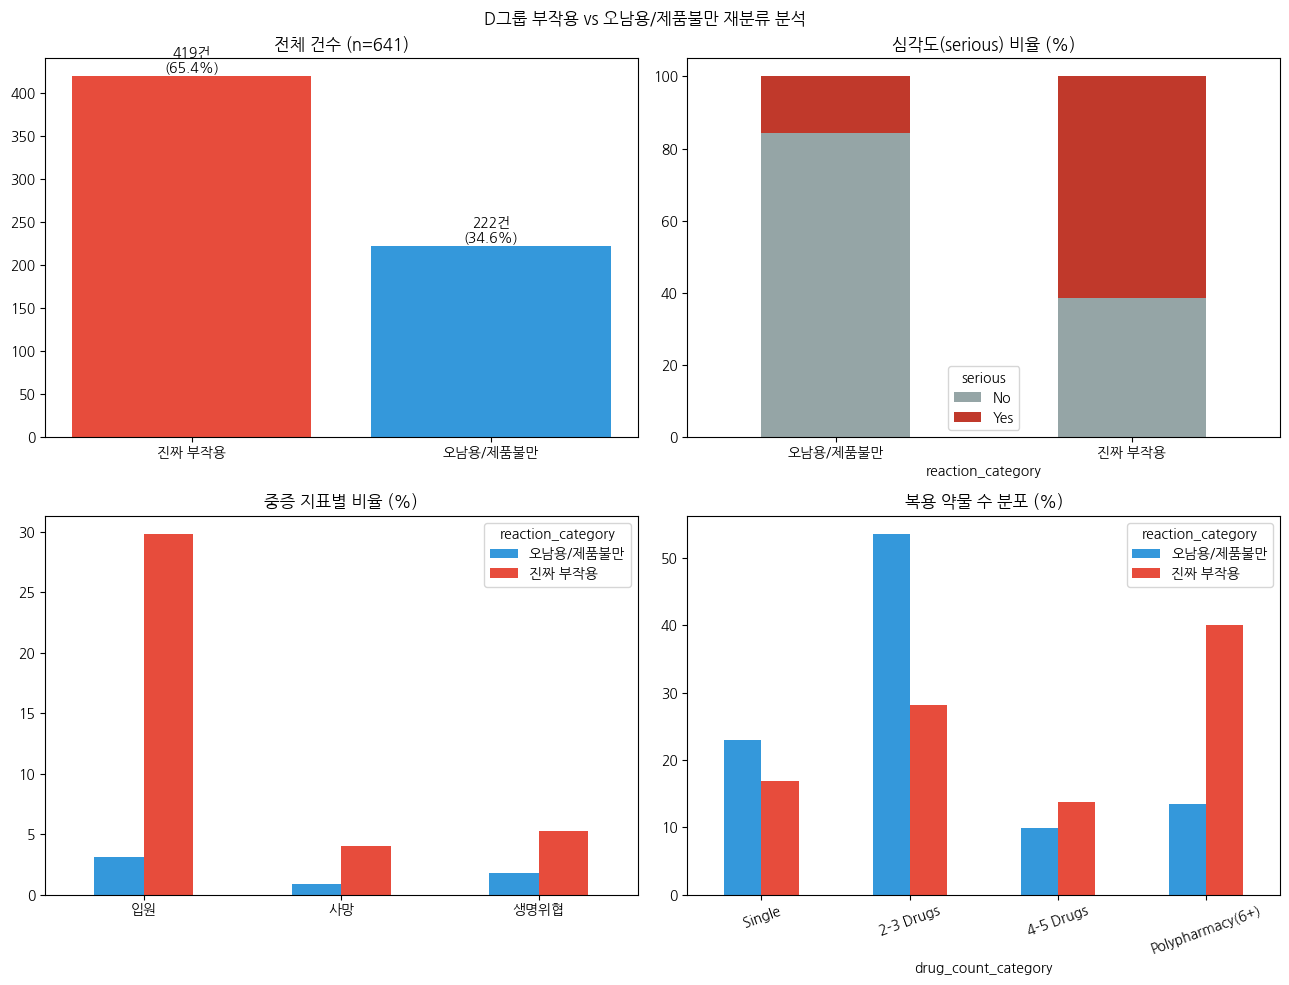

serious: chi2=119.673, p=0.000000
is_hospitalized: chi2=61.547, p=0.000000
is_fatal: chi2=3.989, p=0.045800
is_life_threat: chi2=3.593, p=0.058015
patient_recovered: chi2=55.139, p=0.000000
drug_count_category: chi2=65.287, p=0.000000


In [8]:
# D그룹: 부작용 vs 오남용/제품불만 재분류
misuse_keywords = [
    'ineffective','effect incomplete','effect decreased','response decreased','response unexpected',
    'treatment failure','non-responder','resistance','off label','product use','product complaint',
    'product quality','product formulation','product packaging','product odour','product taste',
    'expired product','counterfeit','product substitution','product package','wrong technique',
    'wrong patient','incorrect dose','incorrect route','incorrect product administration',
    'inappropriate schedule','medication error','administration error','extra dose','dose omission',
    'prescribing error','contraindicated product','intentional product','without a prescription',
    'overdose','inappropriate site','exposure during pregnancy','exposure via',
    'wrong technique in drug','incorrect route of product'
]
pattern = '|'.join(misuse_keywords)
d['reaction_category'] = d['primary_reaction'].str.lower().str.contains(pattern, regex=True).map({True: '오남용/제품불만', False: '진짜 부작용'})
print(d['reaction_category'].value_counts())
print((d['reaction_category'].value_counts(normalize=True)*100).round(1))

colors = {'진짜 부작용': '#e74c3c', '오남용/제품불만': '#3498db'}
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('D그룹 부작용 vs 오남용/제품불만 재분류 분석', fontweight='bold')

counts = d['reaction_category'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0,0].set_title(f'전체 건수 (n={len(d)})')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+5, f'{v}건\n({v/len(d)*100:.1f}%)', ha='center', fontweight='bold')

ct_serious = pd.crosstab(d['reaction_category'], d['serious'], normalize='index') * 100
ct_serious.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#95a5a6','#c0392b'])
axes[0,1].set_title('심각도(serious) 비율 (%)'); axes[0,1].tick_params(axis='x', rotation=0)

metrics = ['is_hospitalized','is_fatal','is_life_threat']
rates = d.groupby('reaction_category')[metrics].mean() * 100
rates.T.plot(kind='bar', ax=axes[1,0], color=[colors[c] for c in rates.index])
axes[1,0].set_title('중증 지표별 비율 (%)')
axes[1,0].set_xticklabels(['입원','사망','생명위협'], rotation=0)

ct_drug = pd.crosstab(d['reaction_category'], d['drug_count_category'], normalize='index')[['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']] * 100
ct_drug.T.plot(kind='bar', ax=axes[1,1], color=[colors[c] for c in ct_drug.index])
axes[1,1].set_title('복용 약물 수 분포 (%)'); axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

for col in ['serious','is_hospitalized','is_fatal','is_life_threat','patient_recovered','drug_count_category']:
    ct = pd.crosstab(d['reaction_category'], d[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f'{col}: chi2={chi2:.3f}, p={p:.6f}')

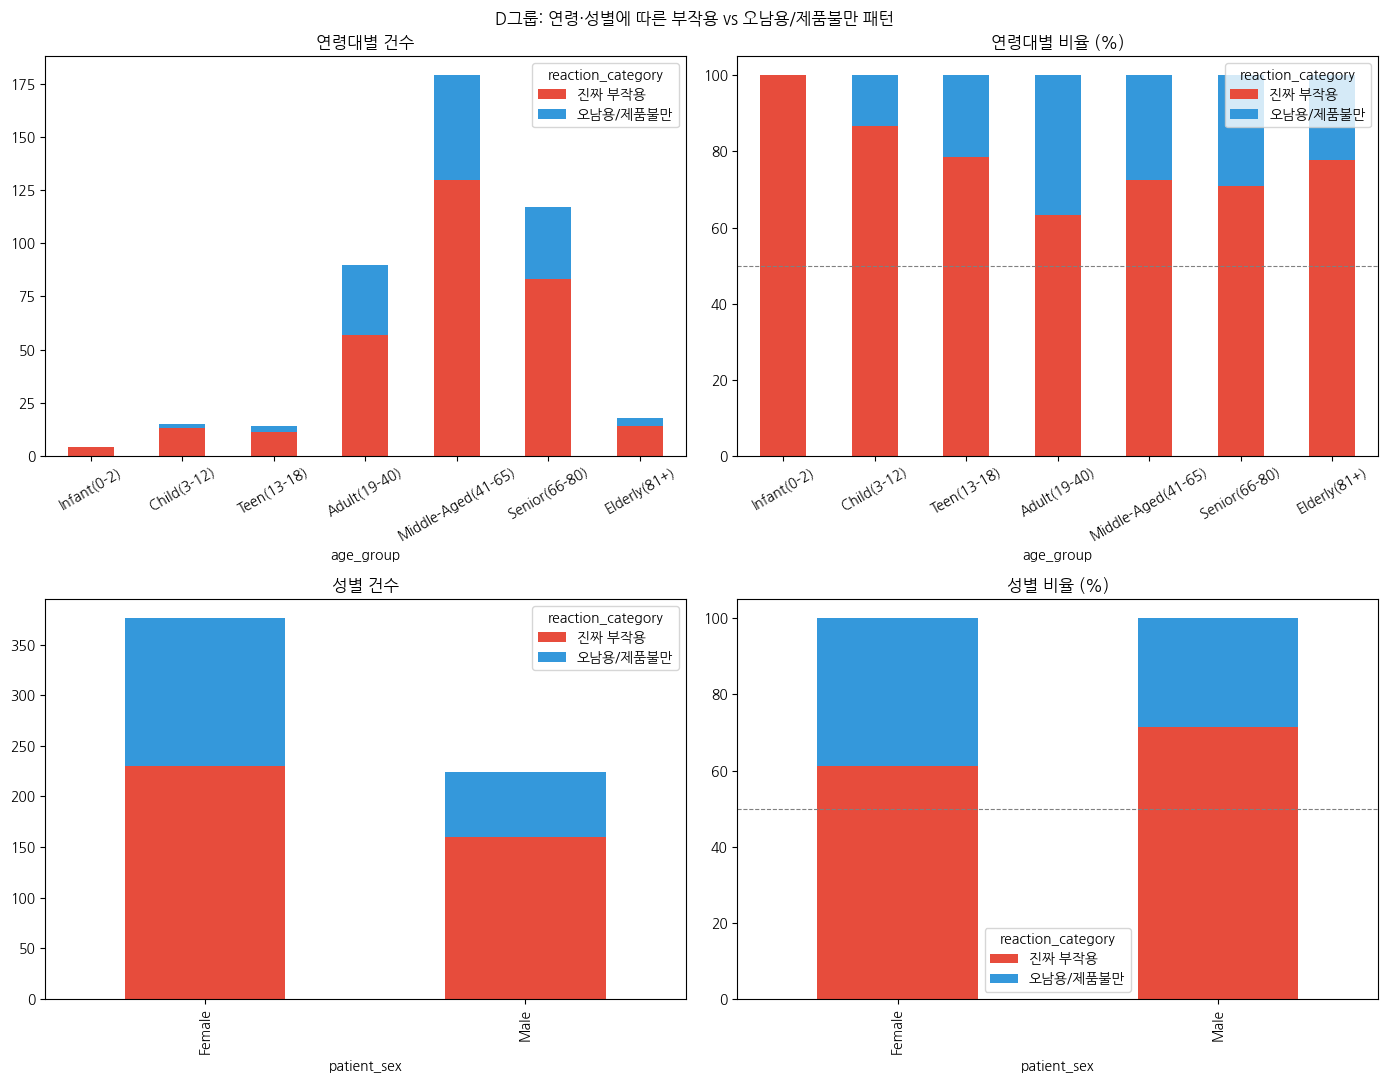

연령대 x 오남용/부작용 카이제곱: chi2=7.037, p=0.317481
성별 x 오남용/부작용 카이제곱: chi2=6.050, p=0.013905

[로지스틱 회귀: 연령대·성별 동시 통제, 종속변수=오남용/제품불만]
                                  Coef.     Std.Err.         z     P>|z|  \
const                        -15.440373  1354.959050 -0.011395  0.990908   
age_group_Child(3-12)         14.171060  1354.959262  0.010459  0.991655   
age_group_Teen(13-18)         14.348591  1354.959202  0.010590  0.991551   
age_group_Adult(19-40)        15.179268  1354.959060  0.011203  0.991062   
age_group_Middle-Aged(41-65)  14.627835  1354.959055  0.010796  0.991386   
age_group_Senior(66-80)       14.711086  1354.959060  0.010857  0.991337   
age_group_Elderly(81+)        14.319182  1354.959165  0.010568  0.991568   
patient_sex_Male              -0.530023     0.233240 -2.272433  0.023060   

                                   [0.025       0.975]  
const                        -2671.111312  2640.230566  
age_group_Child(3-12)        -2641.500295  2669.842414  
age_group_Teen(13-1

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
# D그룹: 연령·성별에 따른 오남용/부작용 패턴 (위 reaction_category 재사용)
age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
d_age = d[d['age_group'] != 'Unknown'].copy()
d_age['age_group'] = pd.Categorical(d_age['age_group'], categories=age_order, ordered=True)
d_sex = d[d['patient_sex'] != 'Unknown'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('D그룹: 연령·성별에 따른 부작용 vs 오남용/제품불만 패턴', fontweight='bold')

ct_age = pd.crosstab(d_age['age_group'], d_age['reaction_category']).reindex(columns=['진짜 부작용','오남용/제품불만'])
ct_age.plot(kind='bar', stacked=True, ax=axes[0,0], color=[colors[c] for c in ct_age.columns])
axes[0,0].set_title('연령대별 건수'); axes[0,0].tick_params(axis='x', rotation=30)

ct_age_pct = pd.crosstab(d_age['age_group'], d_age['reaction_category'], normalize='index')[['진짜 부작용','오남용/제품불만']] * 100
ct_age_pct.plot(kind='bar', stacked=True, ax=axes[0,1], color=[colors[c] for c in ct_age_pct.columns])
axes[0,1].set_title('연령대별 비율 (%)'); axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].axhline(50, color='gray', linestyle='--', linewidth=0.8)

ct_sex = pd.crosstab(d_sex['patient_sex'], d_sex['reaction_category']).reindex(columns=['진짜 부작용','오남용/제품불만'])
ct_sex.plot(kind='bar', stacked=True, ax=axes[1,0], color=[colors[c] for c in ct_sex.columns])
axes[1,0].set_title('성별 건수')

ct_sex_pct = pd.crosstab(d_sex['patient_sex'], d_sex['reaction_category'], normalize='index')[['진짜 부작용','오남용/제품불만']] * 100
ct_sex_pct.plot(kind='bar', stacked=True, ax=axes[1,1], color=[colors[c] for c in ct_sex_pct.columns])
axes[1,1].set_title('성별 비율 (%)')
axes[1,1].axhline(50, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

ct1 = pd.crosstab(d_age['age_group'], d_age['reaction_category'])
chi2, p, dof, _ = chi2_contingency(ct1)
print(f'연령대 x 오남용/부작용 카이제곱: chi2={chi2:.3f}, p={p:.6f}')

ct2 = pd.crosstab(d_sex['patient_sex'], d_sex['reaction_category'])
chi2, p, dof, _ = chi2_contingency(ct2)
print(f'성별 x 오남용/부작용 카이제곱: chi2={chi2:.3f}, p={p:.6f}')

# 연령 x 성별 동시 통제 로지스틱 회귀
d_both = d[(d['age_group'] != 'Unknown') & (d['patient_sex'] != 'Unknown')].copy()
d_both['age_group'] = pd.Categorical(d_both['age_group'], categories=age_order, ordered=True)
d_both['y'] = (d_both['reaction_category'] == '오남용/제품불만').astype(int)
X = sm.add_constant(pd.get_dummies(d_both[['age_group','patient_sex']], drop_first=True).astype(float))
model = sm.Logit(d_both['y'], X).fit(disp=0)
print('\n[로지스틱 회귀: 연령대·성별 동시 통제, 종속변수=오남용/제품불만]')
print(model.summary2().tables[1])

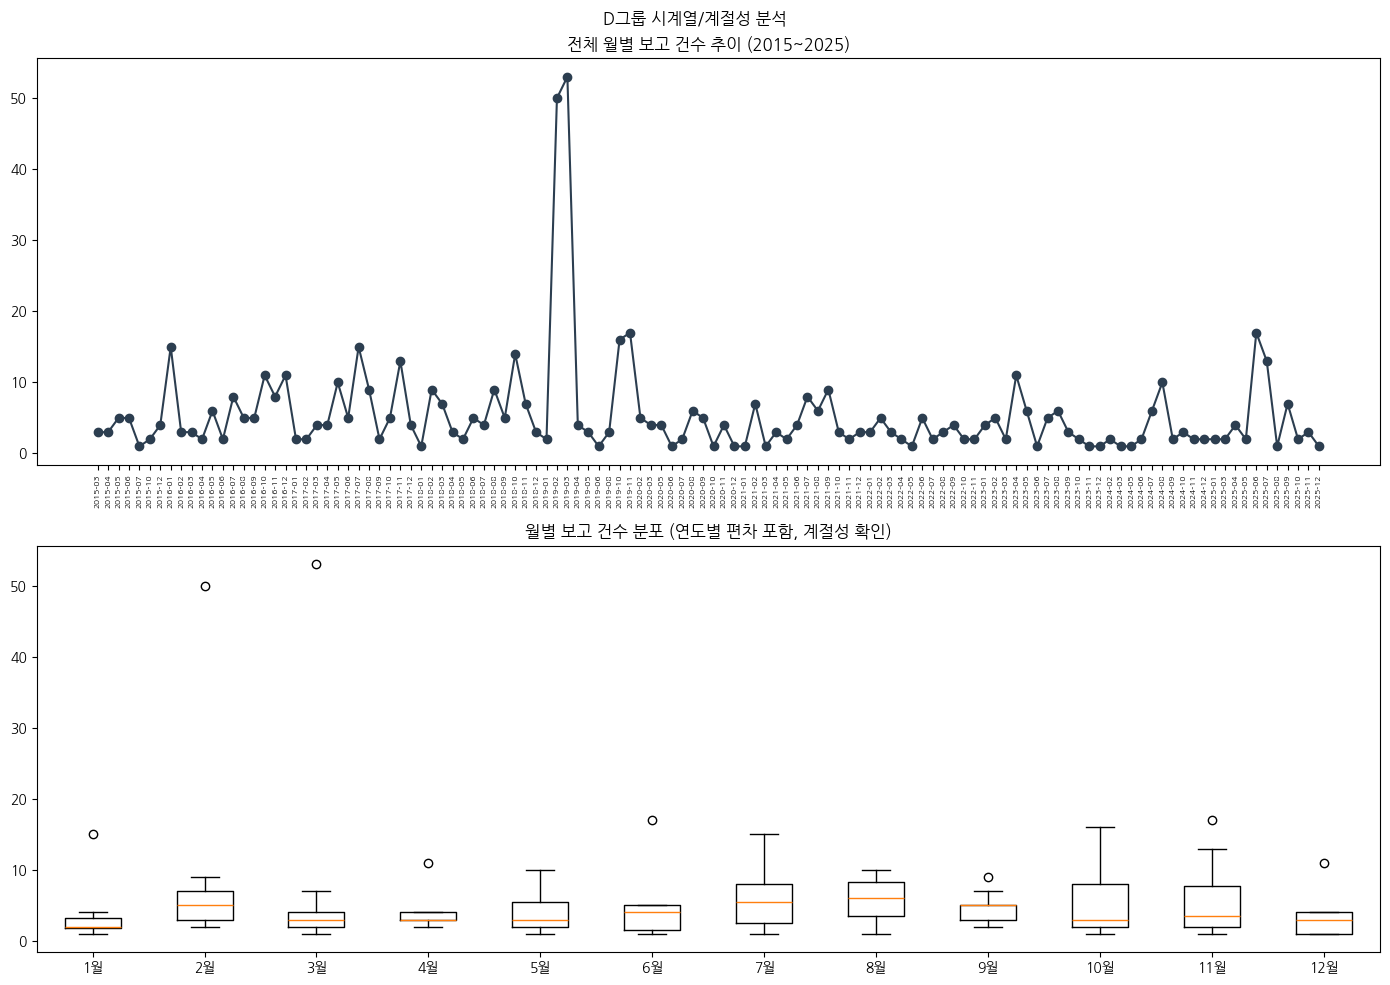

[선형 트렌드] 기울기=-0.0293건/월, R²=0.0196, p=0.130033
[월별 계절성 카이제곱 적합도] chi2=74.563, p=0.000000
serious: 2~3월 11.7% vs 나머지 52.0%
is_hospitalized: 2~3월 3.9% vs 나머지 23.8%
is_fatal: 2~3월 0.0% vs 나머지 3.5%
is_life_threat: 2~3월 1.9% vs 나머지 4.5%
is_disabling: 2~3월 0.0% vs 나머지 4.3%


In [10]:
# D그룹 시계열/계절성 분석
monthly_d = d.groupby('year_month').size()
monthly_d.index = monthly_d.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('D그룹 시계열/계절성 분석', fontweight='bold')

axes[0].plot(monthly_d.index, monthly_d.values, marker='o', color='#2c3e50')
axes[0].set_title('전체 월별 보고 건수 추이 (2015~2025)')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

month_pivot = [d[d['month']==m].groupby('year').size().values for m in range(1,13)]
axes[1].boxplot(month_pivot, tick_labels=[f'{m}월' for m in range(1,13)])
axes[1].set_title('월별 보고 건수 분포 (연도별 편차 포함, 계절성 확인)')
plt.tight_layout()
plt.show()

t = np.arange(len(monthly_d))
slope, intercept, r_value, p_value, _ = linregress(t, monthly_d.values)
print(f'[선형 트렌드] 기울기={slope:.4f}건/월, R²={r_value**2:.4f}, p={p_value:.6f}')

month_totals = d.groupby('month').size().reindex(range(1,13), fill_value=0)
chi2, p = chisquare(month_totals.values, np.full(12, month_totals.sum()/12))
print(f'[월별 계절성 카이제곱 적합도] chi2={chi2:.3f}, p={p:.6f}')

# 특정 기간(2019년 2~3월) 스파이크가 실제 신호인지 확인
mask = (d['receive_date']>='2019-02-01') & (d['receive_date']<='2019-03-31')
feb_mar, rest = d[mask], d[~mask]
for col in ['serious','is_hospitalized','is_fatal','is_life_threat','is_disabling']:
    fm_rate = (feb_mar[col]=='Yes').mean()*100 if col=='serious' else feb_mar[col].mean()*100
    rest_rate = (rest[col]=='Yes').mean()*100 if col=='serious' else rest[col].mean()*100
    print(f'{col}: 2~3월 {fm_rate:.1f}% vs 나머지 {rest_rate:.1f}%')

Female: 기울기=-0.0325건/월, R²=0.0606, p=0.007221
Male: 기울기=0.0015건/월, R²=0.0003, p=0.856658


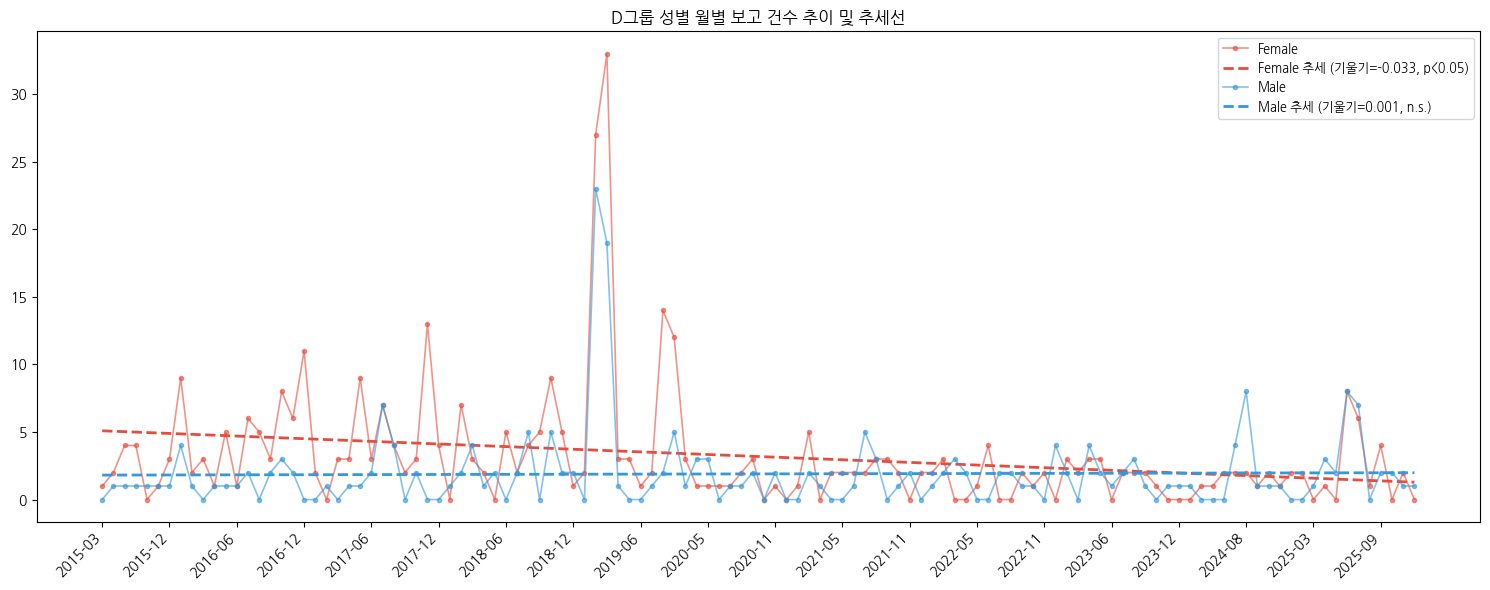

In [11]:
# D그룹 성별 월별 보고 건수 추이 및 추세선
monthly_sex = d.groupby(['year_month','patient_sex']).size().unstack(fill_value=0).reindex(columns=['Female','Male'], fill_value=0)
colors_sex = {'Female': '#e74c3c', 'Male': '#3498db'}
t = np.arange(len(monthly_sex))

fig, ax = plt.subplots(figsize=(15, 6))
for col in monthly_sex.columns:
    y = monthly_sex[col].values
    ax.plot(t, y, marker='o', markersize=3, label=col, color=colors_sex[col], linewidth=1.2, alpha=0.6)
    slope, intercept, r_value, p_value, _ = linregress(t, y)
    sig = 'p<0.05' if p_value < 0.05 else 'n.s.'
    ax.plot(t, slope*t+intercept, linestyle='--', linewidth=2, color=colors_sex[col],
            label=f'{col} 추세 (기울기={slope:.3f}, {sig})')
    print(f'{col}: 기울기={slope:.4f}건/월, R²={r_value**2:.4f}, p={p_value:.6f}')

ax.set_title('D그룹 성별 월별 보고 건수 추이 및 추세선', fontweight='bold')
xticks_pos = range(0, len(monthly_sex), 6)
ax.set_xticks(xticks_pos)
ax.set_xticklabels([str(monthly_sex.index[i]) for i in xticks_pos], rotation=45, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

condition_group
기타/미상      351
국소 피부질환    220
전신 기저질환     70
Name: count, dtype: int64


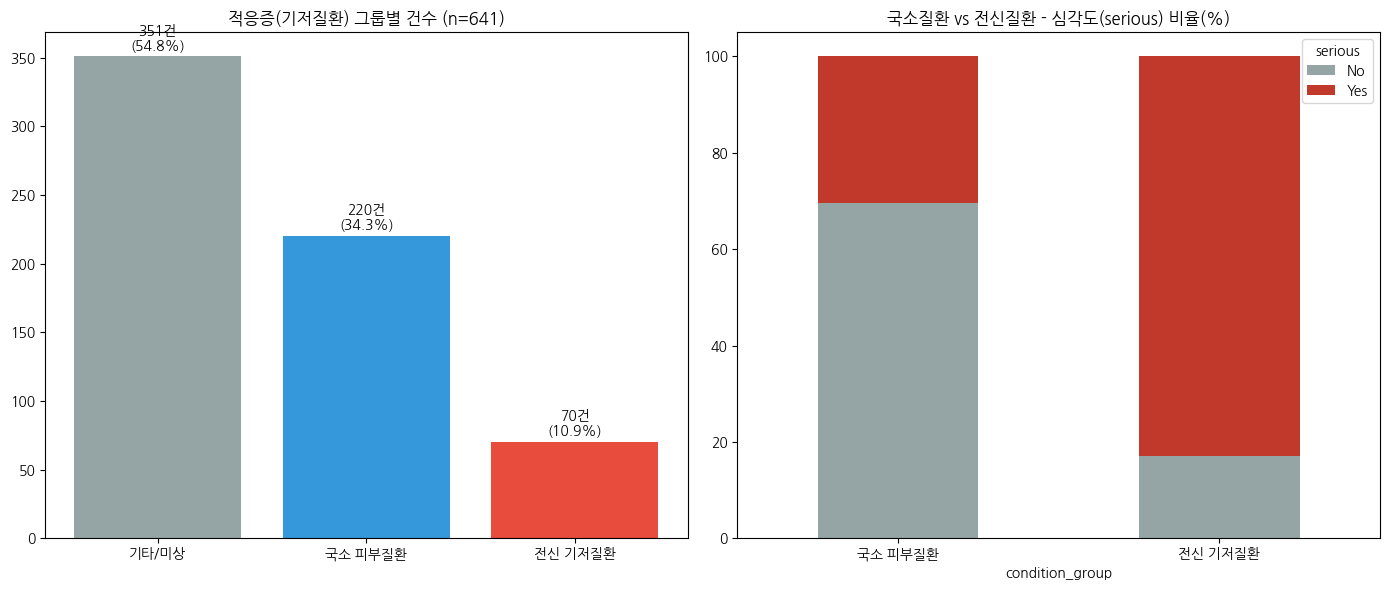

국소 vs 전신 - 심각도 카이제곱: chi2=57.343, p=0.000000
국소 vs 전신 - 입원여부 카이제곱: chi2=42.373, p=0.000000

[전신 기저질환 그룹 세부 적응증]
drug_indication
Adrenal Insufficiency                                    15
Acute Lymphocytic Leukaemia                              15
Hypertension                                              5
Addison^S Disease                                         4
Rheumatoid Arthritis                                      3
Anaplastic Large Cell Lymphoma T- And Null-Cell Types     3
Hyperthyroidism                                           3
Hypopituitarism                                           3
Adrenogenital Syndrome                                    3
Scedosporium Infection                                    3
Juvenile Idiopathic Arthritis                             3
Immunosuppressant Drug Therapy                            3
Arthritis                                                 2
Septic Shock                                              2
Primary Adrenal Insufficiency   

In [12]:
# D그룹 적응증(기저질환) 분류: 국소 피부질환 vs 전신 기저질환
local_skin_keywords = ['alopecia','onychomycosis','trichophytosis','fungal infection','tinea','nail infection',
                       'hair growth','dandruff','acne','eczema','skin lesion','lichen planopilaris','oral herpes']
systemic_keywords = ['adrenal insufficiency','leukaemia','lymphoma','addison','adrenogenital','rheumatoid arthritis',
                     'hyperthyroidism','hypopituitarism','juvenile idiopathic arthritis','immunosuppressant',
                     'septic shock','arthritis','hypertension','scedosporium']

def classify_condition(x):
    x = str(x).lower()
    if any(k in x for k in local_skin_keywords): return '국소 피부질환'
    if any(k in x for k in systemic_keywords): return '전신 기저질환'
    return '기타/미상'

d['condition_group'] = d['drug_indication'].apply(classify_condition)
print(d['condition_group'].value_counts())

colors_cond = {'국소 피부질환': '#3498db', '전신 기저질환': '#e74c3c', '기타/미상': '#95a5a6'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = d['condition_group'].value_counts()
axes[0].bar(counts.index, counts.values, color=[colors_cond[c] for c in counts.index])
axes[0].set_title(f'적응증(기저질환) 그룹별 건수 (n={len(d)})')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, f'{v}건\n({v/len(d)*100:.1f}%)', ha='center')

known = d[d['condition_group'] != '기타/미상']
ct = pd.crosstab(known['condition_group'], known['serious'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#95a5a6','#c0392b'])
axes[1].set_title('국소질환 vs 전신질환 - 심각도(serious) 비율(%)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

ct_raw = pd.crosstab(known['condition_group'], known['serious'])
chi2, p, _, _ = chi2_contingency(ct_raw)
print(f'국소 vs 전신 - 심각도 카이제곱: chi2={chi2:.3f}, p={p:.6f}')

ct_hosp = pd.crosstab(known['condition_group'], known['is_hospitalized'])
chi2, p, _, _ = chi2_contingency(ct_hosp)
print(f'국소 vs 전신 - 입원여부 카이제곱: chi2={chi2:.3f}, p={p:.6f}')

print('\n[전신 기저질환 그룹 세부 적응증]')
print(d[d['condition_group']=='전신 기저질환']['drug_indication'].value_counts())

항진균제 관련 전체 신고 건수: 115건
'병원체 내성' 보고 비율: 13.9%


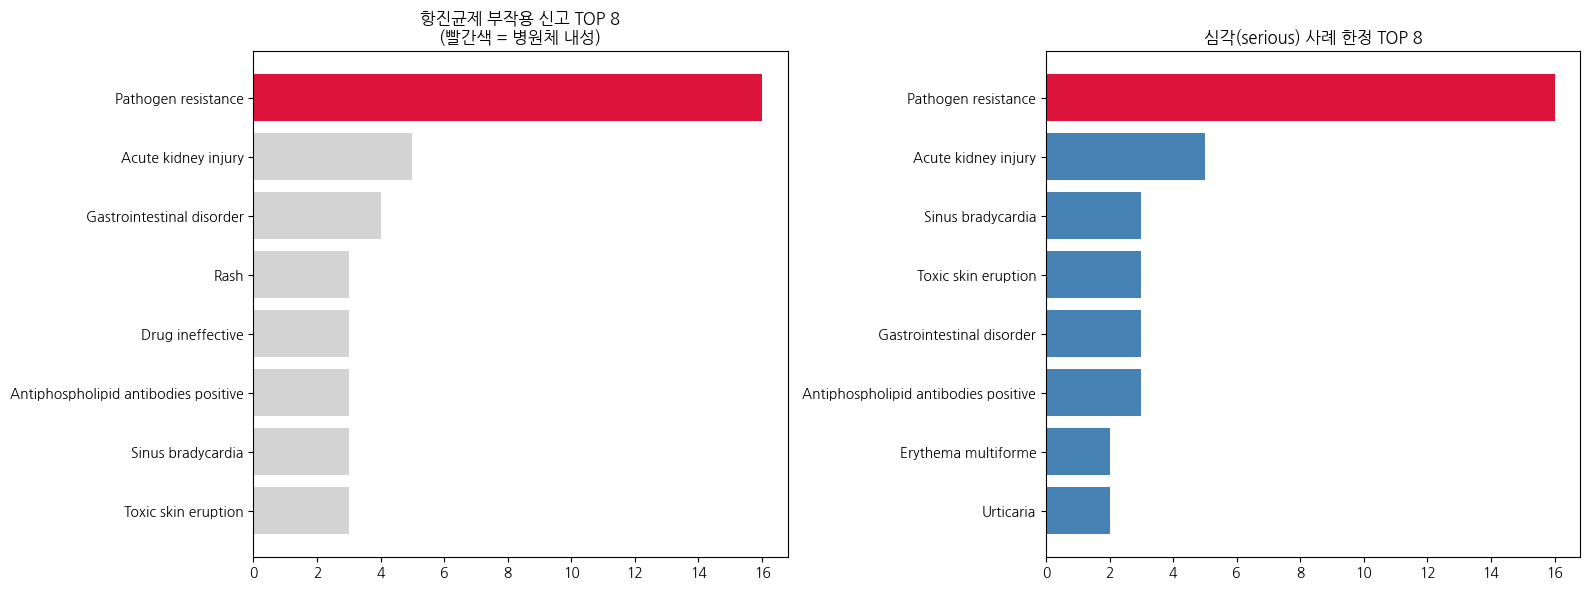


[내성 보고 사례의 의심약물 분포]
suspect_drug
TERBINAFINE HYDROCHLORIDE; TERBINAFINE    16
Name: count, dtype: int64

[내성 보고 사례의 적응증]
drug_indication
Trichophytosis     14
Unknown             1
Dermatophytosis     1
Name: count, dtype: int64


In [13]:
# 항진균제(무좀약) - 병원체 내성(Pathogen resistance) 분석
antifungal = d[d['suspect_drug'].str.contains('TERBINAFINE|CLOTRIMAZOLE|MICONAZOLE|TOLNAFTATE', case=False, na=False)]
print(f'항진균제 관련 전체 신고 건수: {len(antifungal)}건')

reaction_counts = antifungal['primary_reaction'].value_counts()
resistance_rate = (antifungal['primary_reaction']=='Pathogen resistance').mean()*100
print(f"'병원체 내성' 보고 비율: {resistance_rate:.1f}%")

serious_antifungal = antifungal[antifungal['serious']=='Yes']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_reactions = reaction_counts.head(8)
colors_r = ['crimson' if r=='Pathogen resistance' else 'lightgray' for r in top_reactions.index]
axes[0].barh(top_reactions.index[::-1], top_reactions.values[::-1], color=colors_r[::-1])
axes[0].set_title('항진균제 부작용 신고 TOP 8\n(빨간색 = 병원체 내성)')

top_serious = serious_antifungal['primary_reaction'].value_counts().head(8)
colors_r2 = ['crimson' if r=='Pathogen resistance' else 'steelblue' for r in top_serious.index]
axes[1].barh(top_serious.index[::-1], top_serious.values[::-1], color=colors_r2[::-1])
axes[1].set_title('심각(serious) 사례 한정 TOP 8')
plt.tight_layout()
plt.show()

resistance_cases = antifungal[antifungal['primary_reaction']=='Pathogen resistance']
print('\n[내성 보고 사례의 의심약물 분포]'); print(resistance_cases['suspect_drug'].value_counts())
print('\n[내성 보고 사례의 적응증]'); print(resistance_cases['drug_indication'].value_counts())